In [1]:
import importlib
import czyszczenie_danych
import obliczenia
import wykresy
from wczytywanie import load_all_data, load_metadane, load_metadane2

In [2]:
# id archiwum dla poszczególnych lat
gios_url_ids = {2015: '236', 2018: '603', 2021: '486', 2024: '582'} #specjalnie w pliku jupytera, żeby użytkownik mógł łatwo wykonać operacje dla innych danych
gios_pm25_file = {2015: '2015_PM25_1g.xlsx', 2018: '2018_PM25_1g.xlsx', 2021: '2021_PM25_1g.xlsx', 2024: '2024_PM25_1g.xlsx'}

In [3]:
raw_all_data = load_all_data(gios_url_ids, gios_pm25_file)

Wczytywanie roku 2015...
Wczytywanie roku 2018...
Wczytywanie roku 2021...
Wczytywanie roku 2024...


<font size="6">Wygląd surowych danych</font>

In [5]:
raw_all_data[2015]

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,Kod stacji,DsJelGorOgin,DsWrocAlWisn,DsWrocWybCon,KpBydPlPozna,KpBydWarszaw,KpToruDziewu,LbLubObywate,LdLodzCzerni,LdLodzGdansk,...,SkMalo11List,SkPolaRuszcz,SlGliwicMewy,SlKatoKossut,SlZlotPotLes,WmOlsPuszkin,WpKaliSawick,WpPoznPolank,ZpSzczAndr01,ZpSzczPils02
1,Wskaźnik,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,...,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5
2,Czas uśredniania,1g,1g,1g,1g,1g,1g,1g,1g,1g,...,1g,1g,1g,1g,1g,1g,1g,1g,1g,1g
3,2015-01-01 01:00:00,151.112,78,50,29.2,95.5,27.352,71.1012,59.73,NaN,...,39.6,72.4,77.828,51.389,49.9464,44.060833,25.5,24.4768,NaN,NaN
4,2015-01-01 02:00:00,262.566,42,33.8244,27.1,86.1,78.0064,95.2582,185.92,NaN,...,33.6,57.2,50.0552,37.709,45.6291,49.943329,32.5,29.86,81.8501,215.379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,2015-12-31 20:00:43.770000,13.7734,29.2072,24.4965,NaN,76.2,NaN,62.7976,31,57,...,28,59,205.944,158.52,42.9334,34.510277,75.05,36.3858,30.6219,30.2969
8759,2015-12-31 21:00:43.775000,20.8195,36.8677,39.4025,55.4,66.9,NaN,105.59,46,60,...,36.8,57.4,218.516,143.729,45,35.861,62.8491,40.31,50.1254,27.2376
8760,2015-12-31 22:00:43.780000,11.7978,61.041,52.4493,NaN,69.2,NaN,232.0938,46,58,...,33.3,73.8,169.238,131.673,63.9197,36.309914,70.6655,43.079,38.0602,28.3642
8761,2015-12-31 23:00:43.785000,16.6281,67.5414,59.3307,71.1,65.5,NaN,203.4012,49,57,...,38.2,70.9,115.688,119.533,56.2223,38.686676,80.2882,52.32,193.129,34.8272


In [6]:
raw_all_data[2018]

,0,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,49,50,51
0,Nr,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,49,50,51
1,Kod stacji,DsJelGorOgin,DsWrocAlWisn,DsWrocWybCon,KpBydPlPozna,KpBydWarszaw,KpToruDziewu,KpWloclOkrze,LbLubObywate,LdLodzCzerni,...,SkKonsGranatMOB,SkPolaRuszcz,SlBielPartyz,SlKatoKossut,SlZlotPotLes,WmOlsPuszkin,WpKaliSawick,WpPoznDabrow,ZpSzczAndr01,ZpSzczPils02
2,Wskaźnik,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,...,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5
3,Czas uśredniania,1g,1g,1g,1g,1g,1g,1g,1g,1g,...,1g,1g,1g,1g,1g,1g,1g,1g,1g,1g
4,Jednostka,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,...,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8761,2018-12-31 20:00:00,"99,2267","43,6255","32,0664","32,95258","37,0","19,9155","49,0272","13,1","27,547",...,NaN,"9,05","37,0833","39,3415","16,6016","20,2928","19,1919","39,9397","15,9911","17,2711"
8762,2018-12-31 21:00:00,"99,0422","39,6576","41,8542","24,06","21,5","27,353","37,1728","13,5","29,341",...,NaN,"12,41","44,4883","44,4603","22,982","19,2542","29,3164","42,7089","22,6865","18,7469"
8763,2018-12-31 22:00:00,"126,327","31,3481","30,4876","15,28759","21,3","28,4905","34,2092","15,0","27,547",...,NaN,"13,85","36,596","48,8999","30,555","16,4678","33,0235","42,4264","16,6687","23,7844"
8764,2018-12-31 23:00:00,"100,4","40,2615","30,8172","18,0515","20,2",NaN,"40,5188","11,5","27,547",...,NaN,"13,61","58,2189","42,6519","22,8511","17,3469","39,4939","47,3919","14,7215","20,0236"


In [7]:
raw_all_data[2021]

,0,1,2,3,4,5,6,7,8,9,...,79,80,81,82,83,84,85,86,87,88
0,Nr,1,2,3,4,5,6,7,8,9,...,79,80,81,82,83,84,85,86,87,88
1,Kod stacji,DsJelGorOgin,DsKlodzSzkol,DsMiliczMOB,DsSrodaSlMOB,DsWrocAlWisn,DsWrocWybCon,KpBydPlPozna,KpBydWarszaw,KpNaklWawrzy,...,WmElbBazynsk,WmElkStadion,WmOlsPuszkin,WmOstrPilsud,WpKaliSawick,WpPoznDabrow,WpSzamotKollMOB,ZpKolKasprowMOB,ZpSzczAndrze,ZpSzczPilsud
2,Wskaźnik,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,...,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5
3,Czas uśredniania,1g,1g,1g,1g,1g,1g,1g,1g,1g,...,1g,1g,1g,1g,1g,1g,1g,1g,1g,1g
4,Jednostka,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,...,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8761,2021-12-31 20:00:00,3.12917,7.45143,11.679,22.8923,17.373,13.2676,5.3,4.2,9.4,...,14.7273,2.35667,6.88431,8.20777,12.7147,9.6095,12.088,NaN,28.2922,16.535
8762,2021-12-31 21:00:00,3.85694,8.97931,9.99029,11.3311,15.2073,7.0746,6.1,4,10.8,...,15.4555,2.26,4.2802,8.16938,10.4441,8.01051,5.43131,NaN,20.6238,11.8592
8763,2021-12-31 22:00:00,4.06833,9.84656,8.56565,8.53965,11.9503,6.50143,5.9,4.2,8,...,25.1897,2.17639,2.84247,NaN,8.76033,6.09901,5.66455,NaN,33.4185,9.46917
8764,2021-12-31 23:00:00,4.27861,13.6206,7.59395,8.59608,8.05353,6.03857,NaN,5.7,8.7,...,23.361,2.07222,9.30276,8.48576,7.16033,6.06667,6.53482,NaN,29.9923,7.56722


In [8]:
raw_all_data[2024]

,0,1,2,3,4,5,6,7,8,9,...,87,88,89,90,91,92,93,94,95,96
0,Nr,1,2,3,4,5,6,7,8,9,...,87,88,89,90,91,92,93,94,95,96
1,Kod stacji,DsChojnowMalMOB,DsJelGorOgin,DsKlodzSzkol,DsKudowaSzkoMOB,DsWrocAlWisn,DsWrocWybCon,KpBydPlPozna,KpBydWarszaw,KpNaklWawrzy,...,WmElkStadion,WmOlsPuszkin,WpKaliSawick,WpKoscianMayMOB,WpPoznDabrow,WpPoznSzwajc,ZpDabkiSztorMOB,ZpKolZolkiew,ZpSzczAndrze,ZpSzczPilsud
2,Wskaźnik,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,...,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5,PM2.5
3,Czas uśredniania,1g,1g,1g,1g,1g,1g,1g,1g,1g,...,1g,1g,1g,1g,1g,1g,1g,1g,1g,1g
4,Jednostka,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,...,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8785,2024-12-31 20:00:00,53,48.3,34.3,28.4,51.4,27.7,5.4,34.1,43.1,...,13.5,16,25.4,NaN,22,35.3,NaN,10.9,8.4,14
8786,2024-12-31 21:00:00,33.7,67,33.3,33.6,65.5,19.9,7.7,34.6,29.4,...,11.8,19.3,25,NaN,22.9,28.5,NaN,9,12.8,12.7
8787,2024-12-31 22:00:00,57.7,72.7,32.4,44.1,30.2,17.4,14.5,29.3,12.7,...,9.6,26.9,24,NaN,21.3,23.4,NaN,8.2,20.7,12.1
8788,2024-12-31 23:00:00,75.5,79.9,30.7,56.2,36,23.6,NaN,16,11.6,...,14,23,23.6,NaN,23.2,24.2,NaN,7.8,13.4,12.7


In [9]:
import wczytywanie
importlib.reload(wczytywanie)

<module 'wczytywanie' from '/home/ania/Desktop/Projekt3_ZTP/wczytywanie.py'>

In [10]:
#df_meta = wczytywanie.load_metadane() #za pomocą requests
df_meta = wczytywanie.load_metadane2() #z pliku
# UWAGA: tutaj wykorzystana funkcja, w której czytane są metadane pobrane już na komputerze na wypadek, gdyby strona GIOS nie działała

In [11]:
importlib.reload(czyszczenie_danych)

<module 'czyszczenie_danych' from '/home/ania/Desktop/Projekt3_ZTP/czyszczenie_danych.py'>

<font size="6">Przygotowanie danych do analizy</font>

In [12]:
cleared_all_data = czyszczenie_danych.prepare_to_analize(raw_all_data, df_meta)

Liczba stacji: 42
Liczba dni w roku 2015, w których wykonywano pomiary: 365
Liczba stacji: 51
Liczba dni w roku 2018, w których wykonywano pomiary: 365
Liczba stacji: 88
Liczba dni w roku 2021, w których wykonywano pomiary: 365
Liczba stacji: 96
Liczba dni w roku 2024, w których wykonywano pomiary: 366


In [14]:
cleared_all_data[2018]

,czas,stacja,miejscowość,wartość
0,2018-01-01 01:00:00,DsJelGorOgin,Jelenia Góra,"43,0102"
1,2018-01-01 02:00:00,DsJelGorOgin,Jelenia Góra,"5,38425"
2,2018-01-01 03:00:00,DsJelGorOgin,Jelenia Góra,"4,52882"
3,2018-01-01 04:00:00,DsJelGorOgin,Jelenia Góra,"8,68036"
4,2018-01-01 05:00:00,DsJelGorOgin,Jelenia Góra,"7,2"
...,...,...,...,...
446755,2018-12-31 20:00:00,ZpSzczPilsud,Szczecin,"17,2711"
446756,2018-12-31 21:00:00,ZpSzczPilsud,Szczecin,"18,7469"
446757,2018-12-31 22:00:00,ZpSzczPilsud,Szczecin,"23,7844"
446758,2018-12-31 23:00:00,ZpSzczPilsud,Szczecin,"20,0236"


In [15]:
cleared_all_data[2015]

,czas,stacja,miejscowość,wartość
0,2015-01-01 01:00:00.000,DsJelGorOgin,Jelenia Góra,151.112
1,2015-01-01 02:00:00.000,DsJelGorOgin,Jelenia Góra,262.566
2,2015-01-01 03:00:00.005,DsJelGorOgin,Jelenia Góra,222.83
3,2015-01-01 04:00:00.010,DsJelGorOgin,Jelenia Góra,210.767
4,2015-01-01 05:00:00.015,DsJelGorOgin,Jelenia Góra,191.211
...,...,...,...,...
367915,2015-12-31 20:00:43.770,ZpSzczPilsud,Szczecin,30.2969
367916,2015-12-31 21:00:43.775,ZpSzczPilsud,Szczecin,27.2376
367917,2015-12-31 22:00:43.780,ZpSzczPilsud,Szczecin,28.3642
367918,2015-12-31 23:00:43.785,ZpSzczPilsud,Szczecin,34.8272


In [16]:
cleared_all_data[2021]

,czas,stacja,miejscowość,wartość
0,2021-01-01 01:00:00,DsJelGorOgin,Jelenia Góra,197.186
1,2021-01-01 02:00:00,DsJelGorOgin,Jelenia Góra,183.49
2,2021-01-01 03:00:00,DsJelGorOgin,Jelenia Góra,171.491
3,2021-01-01 04:00:00,DsJelGorOgin,Jelenia Góra,160.902
4,2021-01-01 05:00:00,DsJelGorOgin,Jelenia Góra,145.648
...,...,...,...,...
770875,2021-12-31 20:00:00,ZpSzczPilsud,Szczecin,16.535
770876,2021-12-31 21:00:00,ZpSzczPilsud,Szczecin,11.8592
770877,2021-12-31 22:00:00,ZpSzczPilsud,Szczecin,9.46917
770878,2021-12-31 23:00:00,ZpSzczPilsud,Szczecin,7.56722


In [17]:
cleared_all_data[2024]

,czas,stacja,miejscowość,wartość
0,2024-01-01 01:00:00,DsChojnowMalMOB,Chojnów,NaN
1,2024-01-01 02:00:00,DsChojnowMalMOB,Chojnów,NaN
2,2024-01-01 03:00:00,DsChojnowMalMOB,Chojnów,NaN
3,2024-01-01 04:00:00,DsChojnowMalMOB,Chojnów,NaN
4,2024-01-01 05:00:00,DsChojnowMalMOB,Chojnów,NaN
...,...,...,...,...
843259,2024-12-31 20:00:00,ZpSzczPilsud,Szczecin,14
843260,2024-12-31 21:00:00,ZpSzczPilsud,Szczecin,12.7
843261,2024-12-31 22:00:00,ZpSzczPilsud,Szczecin,12.1
843262,2024-12-31 23:00:00,ZpSzczPilsud,Szczecin,12.7


<font size="6">Złączenie danych z wielu lat w jeden DateFrame</font>

In [15]:
final_df = czyszczenie_danych.combine_years(cleared_all_data)

Liczba unikalnych kodów stacji: 30
Liczba dni w roku 2015: 365
Liczba dni w roku 2016: 1
Liczba dni w roku 2018: 365
Liczba dni w roku 2021: 365
Liczba dni w roku 2024: 366


In [19]:
final_df

,czas,stacja,wartość,miejscowość,rok
0,2015-01-01 01:00:00.000,DsJelGorOgin,151.112,Jelenia Góra,2015
1,2015-01-01 02:00:00.000,DsJelGorOgin,262.566,Jelenia Góra,2015
2,2015-01-01 03:00:00.005,DsJelGorOgin,222.83,Jelenia Góra,2015
3,2015-01-01 04:00:00.010,DsJelGorOgin,210.767,Jelenia Góra,2015
4,2015-01-01 05:00:00.015,DsJelGorOgin,191.211,Jelenia Góra,2015
...,...,...,...,...,...
1051915,2024-12-31 20:00:00.000,ZpSzczPilsud,14,Szczecin,2024
1051916,2024-12-31 21:00:00.000,ZpSzczPilsud,12.7,Szczecin,2024
1051917,2024-12-31 22:00:00.000,ZpSzczPilsud,12.1,Szczecin,2024
1051918,2024-12-31 23:00:00.000,ZpSzczPilsud,12.7,Szczecin,2024


In [20]:
#zapisanie zbiorczego, oczyszczonego i ujednoliconego DateFrame do pliku, do którego pliku to dać?
final_df.to_csv("danePM25_2015_2018_2021_2024.csv", index=True)

<font size="6">Zadanie 2</font>

In [30]:
importlib.reload(obliczenia)

<module 'obliczenia' from '/home/ania/Desktop/Projekt3_ZTP/obliczenia.py'>

In [16]:
# Dodanie miesiąca
final_df = obliczenia.add_month_column(final_df)

<font size="6">Średnie miesięczne dla każdej stacji i roku</font>

In [23]:
mean_month = obliczenia.count_monthly_avg_station(final_df)
mean_month

,rok,stacja,miesiąc,średnie_PM25
0,2015,DsJelGorOgin,1,24.520156
1,2015,DsJelGorOgin,2,41.776451
2,2015,DsJelGorOgin,3,28.692497
3,2015,DsJelGorOgin,4,12.297509
4,2015,DsJelGorOgin,5,8.736347
...,...,...,...,...
1465,2024,ZpSzczPilsud,8,12.771909
1466,2024,ZpSzczPilsud,9,16.876111
1467,2024,ZpSzczPilsud,10,16.222581
1468,2024,ZpSzczPilsud,11,12.273194


In [24]:
# Średnie miesięczne dla wybranych miast i lat
cities = ['Warszawa', 'Katowice']
years = [2015, 2024]
mean_month_cities = obliczenia.count_monthly_avg_city(final_df, cities, years)

In [37]:
importlib.reload(wykresy)

<module 'wykresy' from '/home/ania/Desktop/Projekt3_ZTP/wykresy.py'>

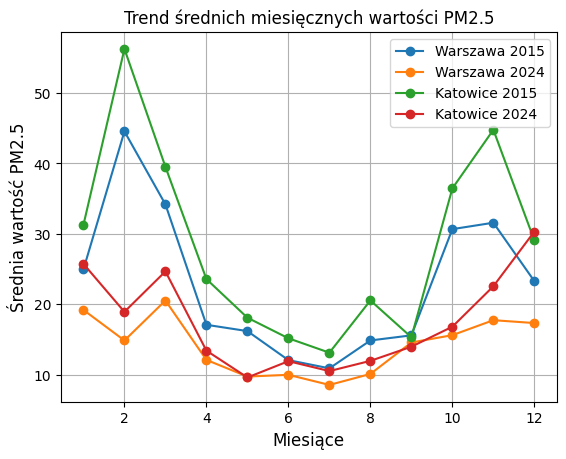

In [25]:
# Rysowanie wykresu
wykresy.city_trends_plot(mean_month_cities, cities, years)

Interpretacja: Wykres powyżej przedstawia średnie stężenie PM2.5 w zależności od miesiąca w latach 2015, 2024 w Warszawie i Katowicach. Nietrudno zauważyć, że w obu miastach w tym czasie stężenie PM2.5 znacznie zmalało. Najmniejsze zmiany na przekroju tych lat obserwujemy w ciepłe, letnie miesiące, zaś w chłodniejszych miesiącach obserwujemy spadek nawet do 38 ug/m3 (luty Katowice). Na wykresie widać także, że w Warszawie przez większość czasu odnotowujemy niższe stężenia pyłów niż w Katowicach.

<font size="6">Zadanie 3</font>

In [31]:
# Średnie miesięczne dla wszystkich miast
mean_month_all_cities = obliczenia.count_monthly_avg_city(final_df)
mean_month_all_cities

,miejscowość,rok,miesiąc,średnie_PM25
0,Białystok,2015,1,22.458108
1,Białystok,2015,2,40.958009
2,Białystok,2015,3,31.035422
3,Białystok,2015,4,13.417614
4,Białystok,2015,5,10.754224
...,...,...,...,...
1195,Żyrardów,2024,8,9.493405
1196,Żyrardów,2024,9,14.392222
1197,Żyrardów,2024,10,16.474124
1198,Żyrardów,2024,11,19.610987


In [32]:
# na tej podstawie określone zostało vmax w funkcji poniżej
max_PM25 = mean_month_all_cities['średnie_PM25'].max()
max_PM25

np.float64(66.83706453125)

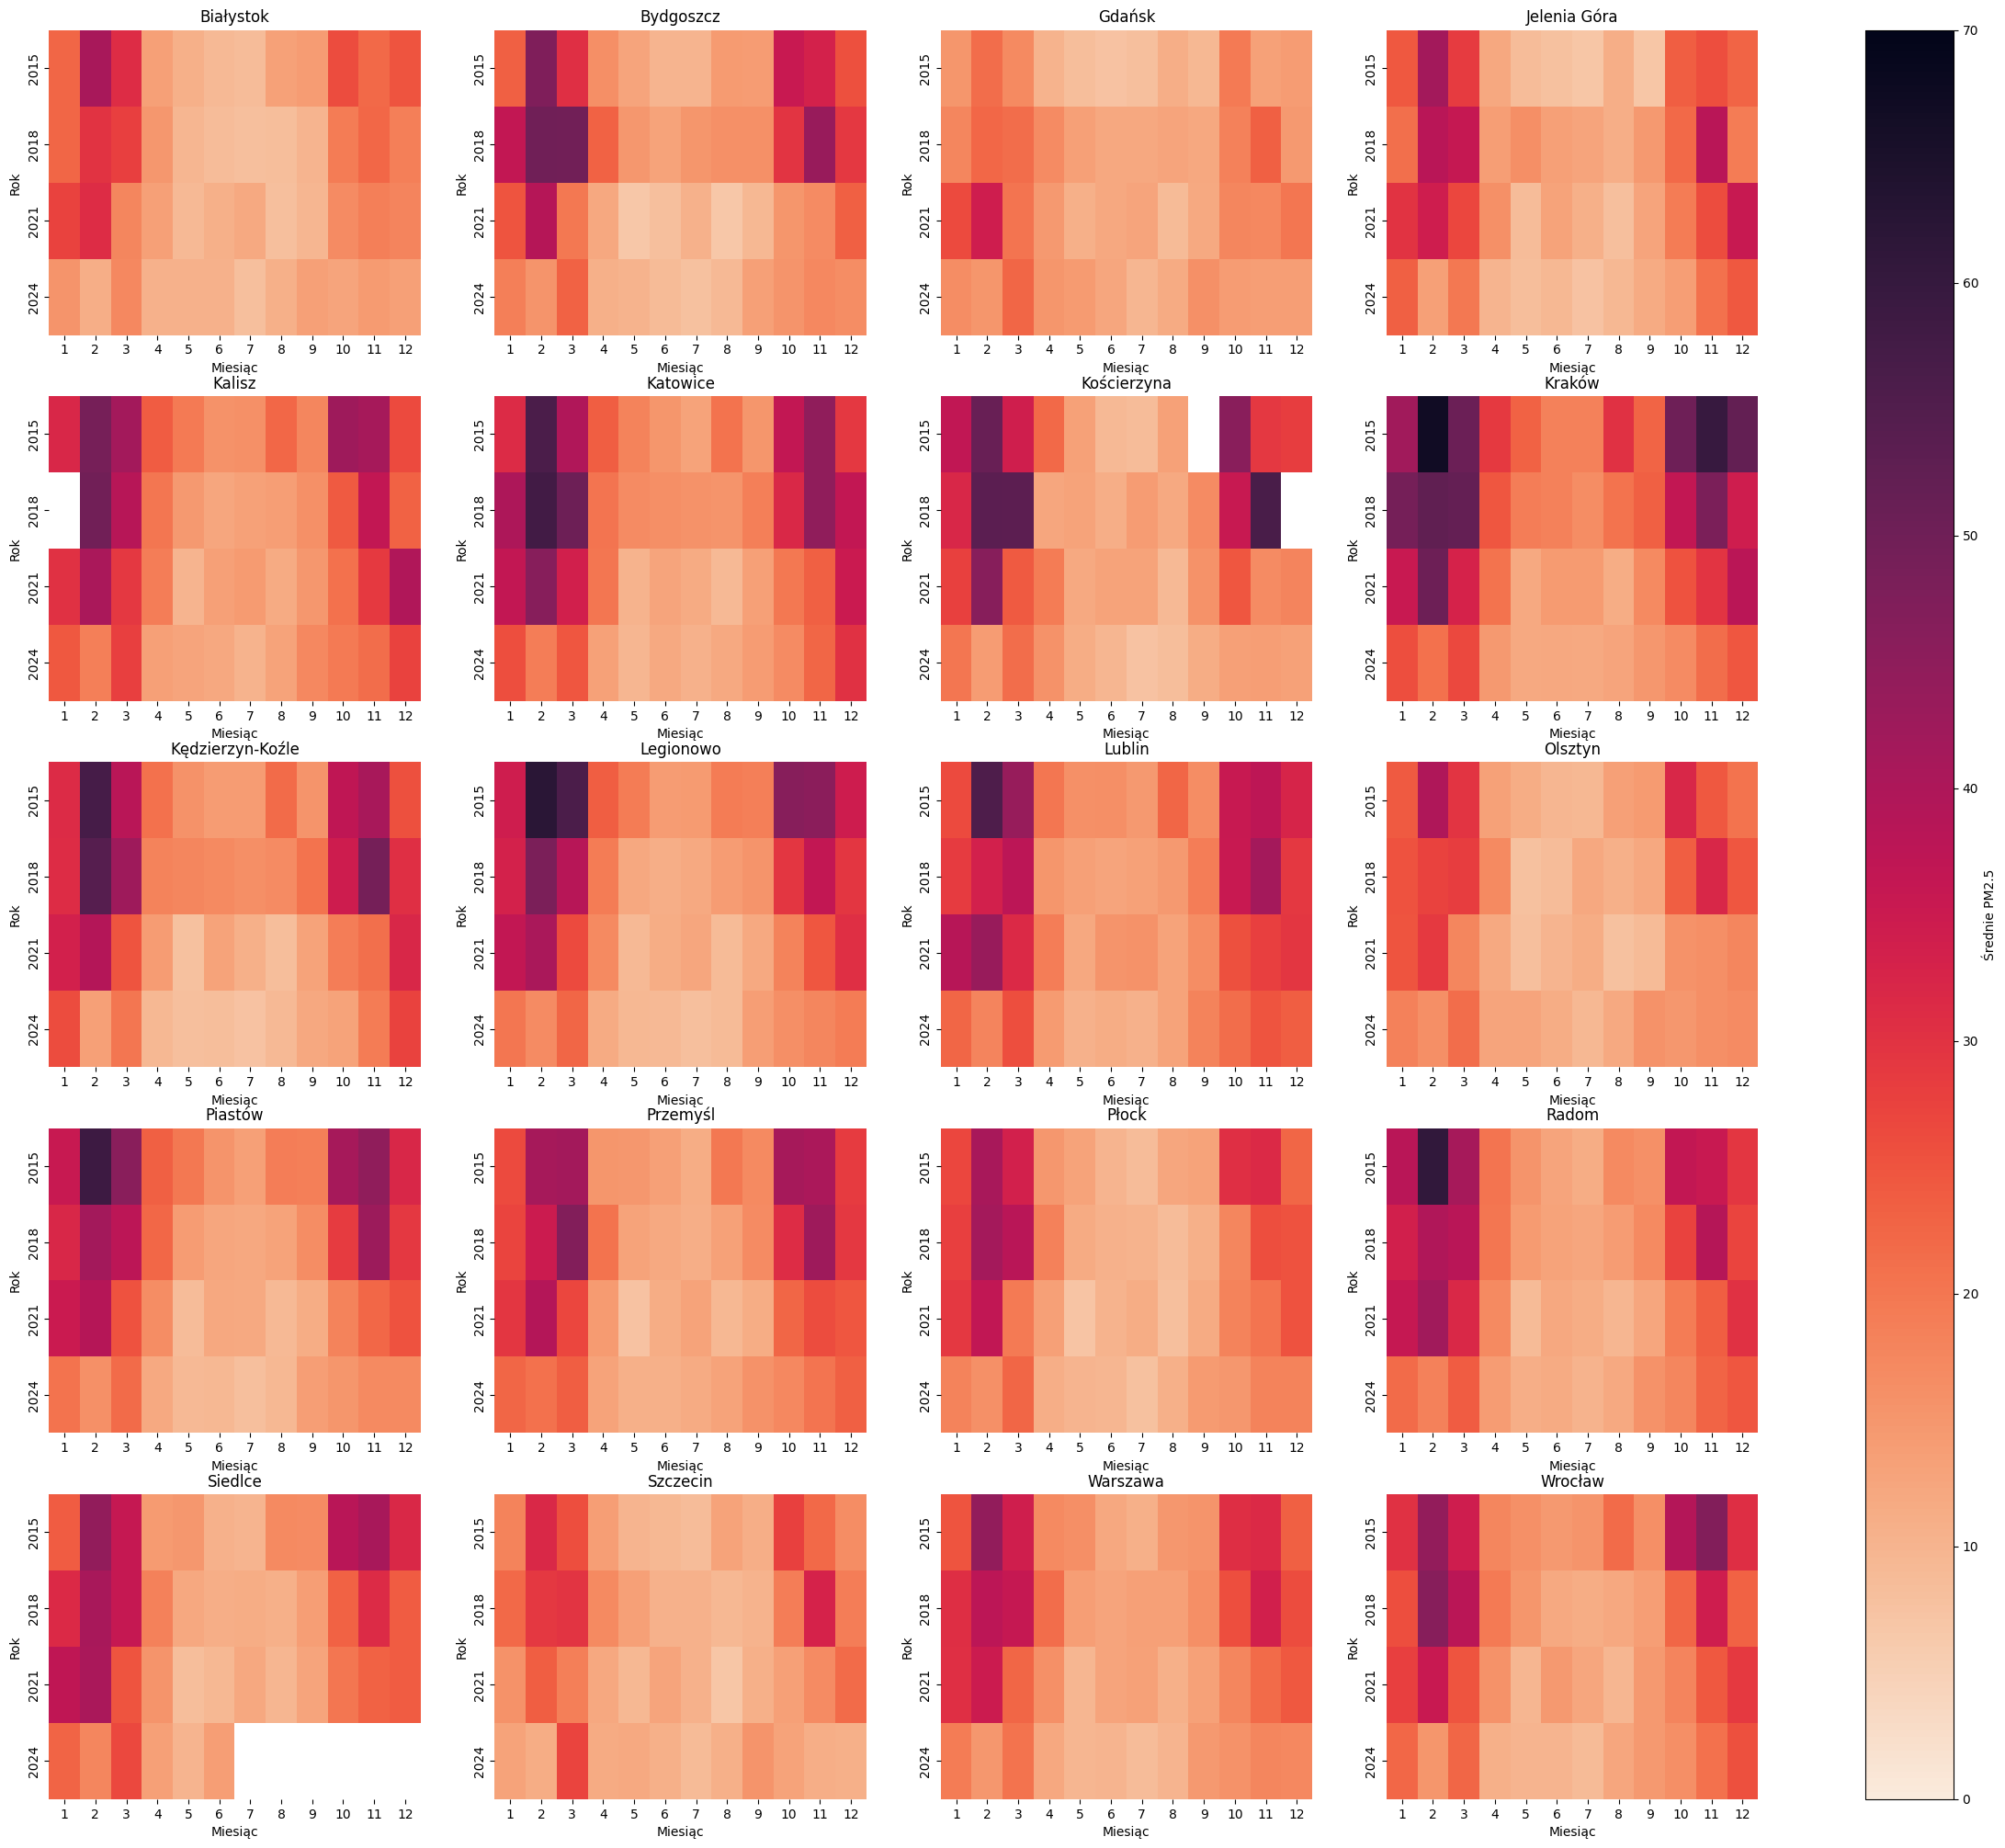

In [33]:
wykresy.heatmap_plot(mean_month_all_cities)

Interpretacja: Powyższe heatmapy przedstawiają średnie stężenie PM2.5 w zależności od miesiąca w latach 2015, 2018, 2021 i 2024 dla poszczególnych miast. Wskazują one na wyraźną poprawę jakości powietrza na przestrzeni lat w zdecydowanej większości z nich, szczególnie w okresie zimowym.

<font size="6">Zadanie 4</font>

In [34]:
data_exceedances = obliczenia.count_daily_avg(final_df)

In [35]:
data_exceedances

,stacja,rok,miejscowość,ilość przekroczeń
20,LbLubObywate,2015,Lublin,275
21,LbLubObywate,2018,Lublin,234
22,LbLubObywate,2021,Lublin,246
23,LbLubObywate,2024,Lublin,170
28,LdZgieMielcz,2015,Zgierz,177
29,LdZgieMielcz,2018,Zgierz,251
30,LdZgieMielcz,2021,Zgierz,201
31,LdZgieMielcz,2024,Zgierz,189
36,MpKrakAlKras,2015,Kraków,345
37,MpKrakAlKras,2018,Kraków,343


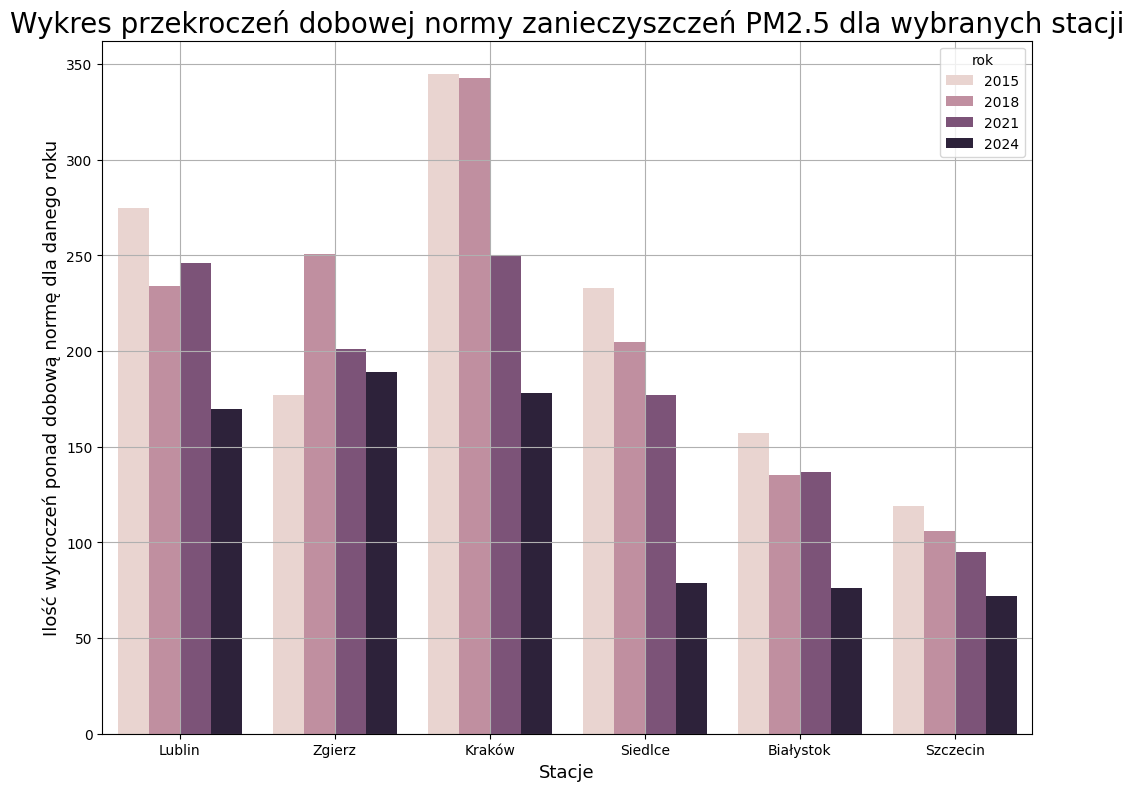

In [38]:
wykresy.barplot(data_exceedances)

Interpretacja: Powyższy grupowy wykres słupkowy przedstawia sumaryczne ilości wykroczeń ponad dobową normę zanieczyszczeń PM2.5 dla wybranych stacji (o największej i najmniejszej liczbie wykroczeń w ciągu roku) w danych miejscowościach w latach 2015, 2018, 2021 i 2024. Widoczne jest, że w roku 2015 nawet stacje o najmniejszej ilości wykroczeń przekraczały normę przynajmniej przez 115 dni w roku, natomiast stacja o najgorszych wynikach przekraczała te normy przez prawie cały rok (w Krakowie). Jednak w kolejnych latach ilość przekroczeń normy znacznie malała w stosunku do lat poprzednich.

<font size="6">Zadanie 5</font>

In [19]:
df_voivodeship = obliczenia.voivodeship_above_norm_sum(df_meta, final_df)

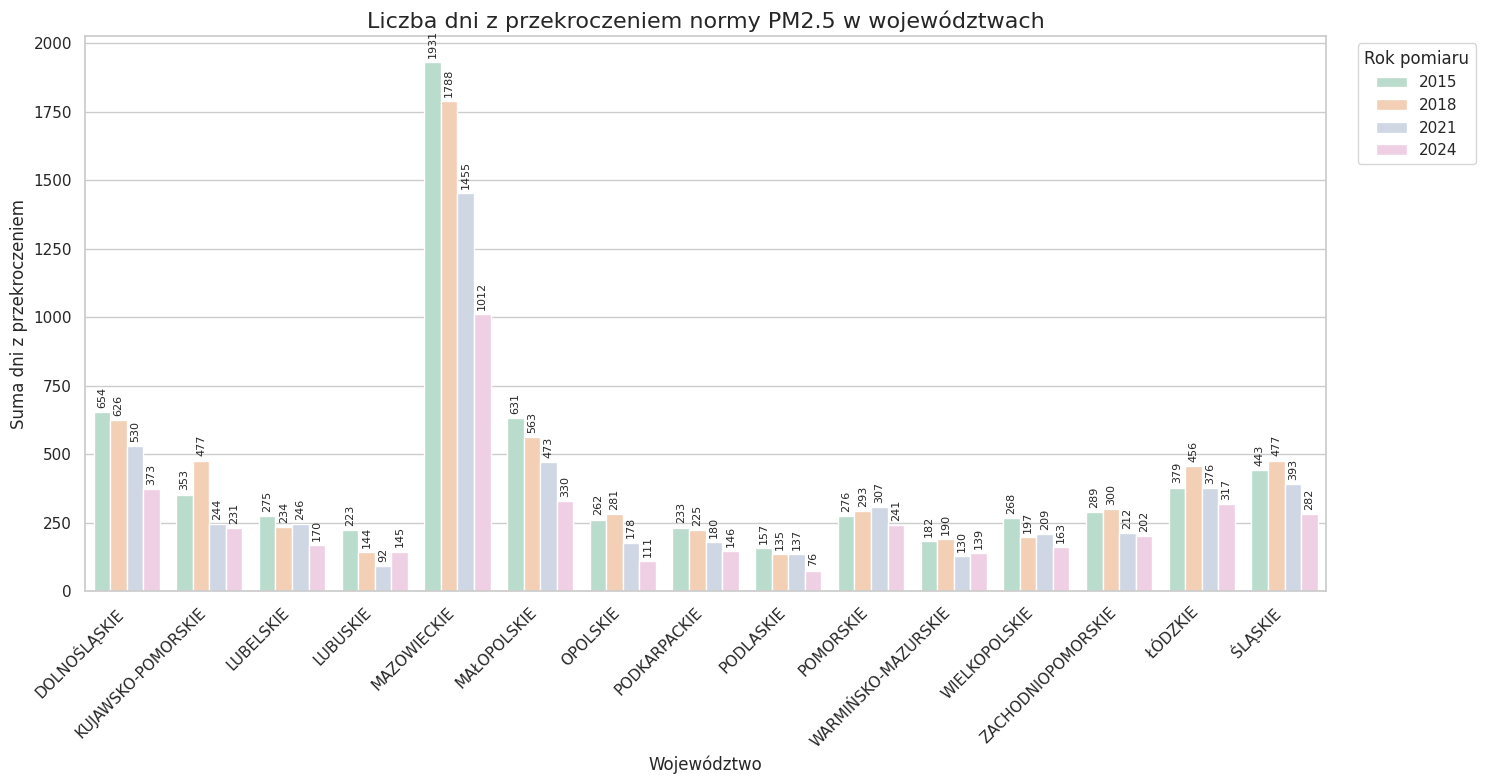

In [20]:
wykresy.plot_voivodeship_comparison(df_voivodeship)

<font size="6">Przykład jak działa update_data (w prepare_to_analize)</font>

In [ ]:
df_test = pd.DataFrame({
    'stacja': ['001', '002', '003', '004'],
    'wartosc': [12, 15, 20, 5]
})

meta_test = pd.DataFrame({
    'Kod stacji': ['101', '102', '103'],
    'Stary Kod stacji \n(o ile inny od aktualnego)': ['001', '003,004', None]
})

df_updated = update_data(df_test, meta_test)

In [ ]:
print("Przed aktualizacją:")
print(df_test)

In [ ]:
print("Po aktualizacji:")
print(df_updated)

In [ ]:
#001 -> 101;
#002 bez zmian (nie jest starym kodem);
#003 i 004 -> 002 (oba są starym kodami, oba zmieniają się na 002)
#103 nie ma starego kodu, ale jest też nieistotny w kontekście df_test